In [1]:
# import required libraries
from ifmiap import utils
from ifmiap import authenticate
from ifmiap import preprocessing
from ifmiap import mapfloods
from ifmiap import postprocessing
import datetime
import pandas as pd
from shapely.affinity import translate

Echoing from here: /Users/pratyusht/Documents/MapSolveAI/ifmiap/ifmiap/__init__.py


/opt/homebrew/lib/python3.9/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
%%time
# process certain squares using a list of grid IDs
selected_grid_id = [190, 104]
aoi_union = utils.gpd_to_json(id_list=selected_grid_id, separate=False) # this is for searching scenes
aoi_list = utils.gpd_to_json(id_list=selected_grid_id, separate=True) # this is to seggregate the search


# define the flood date range
pre_flood_dates = utils.date_range('01/05/2020', 60)
post_flood_dates = utils.date_range('20/07/2020', 8)


# pull sentinel-1 images for pre and post flood duration
pre_s1_scenes = {aoi['properties']['ID']: 
                 utils.search_sentinel_data(
                     bbox = aoi, 
                     start_date = pre_flood_dates[0], 
                     end_date = pre_flood_dates[-1]
                 )
                 for aoi in aoi_union
                }

post_s1_scenes = {aoi['properties']['ID']: 
                 utils.search_sentinel_data(
                     bbox = aoi, 
                     start_date = post_flood_dates[0], 
                     end_date = post_flood_dates[-1]
                 )
                 for aoi in aoi_union
                }

# run this only if the search was performed on the union of AOI
pre_aoi_scene_dict, pre_scene_aoi_dict = utils.seggregate_sentinel_search(aoi_list, pre_s1_scenes)
post_aoi_scene_dict, post_scene_aoi_dict = utils.seggregate_sentinel_search(aoi_list, post_s1_scenes)

for id in pre_aoi_scene_dict:
    print(f'ID: {id}, {len(pre_aoi_scene_dict[id])} pre flood scenes and {len(post_aoi_scene_dict[id])} post flood scenes found.')

ID: 104, 35 pre flood scenes and 7 post flood scenes found.
ID: 190, 25 pre flood scenes and 4 post flood scenes found.
CPU times: user 346 ms, sys: 44.9 ms, total: 391 ms
Wall time: 2.46 s


In [3]:
%%time
stacked_pre = {f'{id}':
                preprocessing.stack_images(pre_aoi_scene_dict[id], id)
                for id in selected_grid_id
               }
stacked_post = {f'{id}':
                preprocessing.stack_images(post_aoi_scene_dict[id], id)
                for id in selected_grid_id
               }

CPU times: user 32.7 s, sys: 4.46 s, total: 37.1 s
Wall time: 8min 55s


In [4]:
%%time
# match the cell size and extent of pre and post images
for id in stacked_pre:
    stacked_post[id]['vv_stack'] = stacked_post[id]['vv_stack'].rio.reproject_match(stacked_pre[id]['vv_stack']).rio.write_transform(stacked_pre[id]['vv_stack'].rio.transform())
    stacked_post[id]['vh_stack'] = stacked_post[id]['vh_stack'].rio.reproject_match(stacked_pre[id]['vh_stack']).rio.write_transform(stacked_pre[id]['vh_stack'].rio.transform())

CPU times: user 109 ms, sys: 25.3 ms, total: 134 ms
Wall time: 134 ms


/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


CPU times: user 442 ms, sys: 86.7 ms, total: 529 ms
Wall time: 529 ms


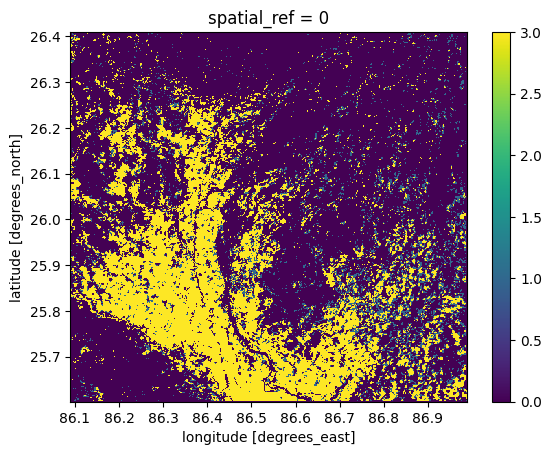

In [5]:
%%time
vv_thd = 2.5
vh_thd = 2.5

flood_dict = {f'{id}':
              mapfloods.anomaly_cells(stacked_pre[f'{id}'], stacked_post[f'{id}'], vv_thd, vh_thd)
              for id in selected_grid_id
             }

for id in flood_dict:
    outfile_flood = f'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/FloodExtent{id}.tif'

    utils.export_xarray(flood_dict[id], outfile_flood)
    
flood_dict[id].plot()

In [27]:
%%time

flood_polygon = pd.concat(
    [
        postprocessing.polygonize_flood_raster(flood_dict[id])
        for id in flood_dict
    ], axis=0)

delta_y = flood_polygon.total_bounds[-1] - flood_polygon.total_bounds[1]
flood_polygon['geometry'] = flood_polygon['geometry'].apply(lambda geom: translate(geom, xoff=0, yoff=delta_y))

flood_polygon.to_file(f'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/FloodExtent.gpkg', index=False)

CPU times: user 1.71 s, sys: 28.4 ms, total: 1.74 s
Wall time: 1.75 s
